# Pythia-1.4B — Permutation Test (1,000 iterations)

**Phase 3:** Permutation-validated causal profile for Pythia-1.4B.

**Hardware:** A100 80GB  
**Runtime:** ~40 minutes

**Run cells 1-8 in order.** (Cells 9+ are diagnostic/exploratory — not needed for replication.)

**Expected outputs:**
- Layers 6, 12: p <= 0.005 **
- Layer 18: p = 0.045 *
- Layer 23 (final): p = 1.000 n.s.
- Saved: `patching_permutation_test_pythia14b.csv`


In [2]:
# Cell 1 — setup (skip if already done this session)
!pip install -q numpy==1.26.4
!pip install -q transformer_lens
from datasets import load_dataset
import os, torch, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformer_lens import HookedTransformer

OUTPUT_DIR = f'/content/drive/MyDrive/ID-UTH-repo/causal_patching'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = 'cuda'
PYTHIA_LAYERS = [6, 12, 18, 23]  # your existing patching layers
N_PAIRS = 10
N_PERM = 1000
print(f'GPU: {torch.cuda.get_device_name(0)}')
print('Ready')

GPU: NVIDIA A100-SXM4-40GB
Ready


In [3]:
# Cell 2 — load BBQ
dataset = load_dataset('Elfsong/BBQ', split='race_ethnicity')
race_df = dataset.to_pandas()
race_ambig = race_df[race_df['context_condition'] == 'ambig'].reset_index(drop=True)

group_indices = {'Hispanic': [], 'Black': []}
for i, row in race_ambig.iterrows():
    context = row['context']
    if 'Hispanic' in context:
        group_indices['Hispanic'].append(i)
    elif 'Black' in context and 'African American' not in context:
        group_indices['Black'].append(i)

hispanic_rows = [race_ambig.iloc[i] for i in group_indices['Hispanic']]
black_rows    = [race_ambig.iloc[i] for i in group_indices['Black']]
print(f'Hispanic: {len(hispanic_rows)}, Black: {len(black_rows)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/age-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

data/disability_status-00000-of-00001.pa(…):   0%|          | 0.00/85.2k [00:00<?, ?B/s]

data/gender_identity-00000-of-00001.parq(…):   0%|          | 0.00/217k [00:00<?, ?B/s]

...

Generating race_x_ses split:   0%|          | 0/11160 [00:00<?, ? examples/s]

Generating religion split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating ses split:   0%|          | 0/6864 [00:00<?, ? examples/s]

Generating sexual_orientation split:   0%|          | 0/864 [00:00<?, ? examples/s]

Hispanic: 164, Black: 236


In [4]:
# Cell 3 — helpers
def format_prompt(row):
    return (
        f"Context: {row['context']}\n"
        f"Question: {row['question']}\n"
        f"A) {row['ans0']}\n"
        f"B) {row['ans1']}\n"
        f"C) {row['ans2']}\n"
        f"Answer:"
    )

def get_label_token_pos(prompt, model, target_word):
    tokens = model.to_tokens(prompt)
    token_strings = [model.to_string(tokens[0][i]) for i in range(tokens.shape[1])]
    for i, tok in enumerate(token_strings):
        if target_word.strip() in tok.strip():
            return i, tokens
    return None, tokens

def kl_divergence(logits_a, logits_b):
    p_a = F.softmax(logits_a.float(), dim=-1)
    p_b = F.softmax(logits_b.float(), dim=-1)
    return F.kl_div(p_b.log(), p_a, reduction='sum').item()

print('Helpers defined.')

Helpers defined.


In [5]:
# Cell 4 — load Pythia-1.4B
print('Loading Pythia-1.4B...')
model = HookedTransformer.from_pretrained(
    'EleutherAI/pythia-1.4b',
    device=DEVICE,
    dtype=torch.float16
)
model.eval()
print('Loaded.')

Loading Pythia-1.4B...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.93G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Loaded pretrained model EleutherAI/pythia-1.4b into HookedTransformer
Loaded.


In [6]:
# Cell 5 — pre-extract all activations for all 20 prompts
print('Pre-extracting activations for all 20 prompts...')

all_prompts = (
    [format_prompt(hispanic_rows[i]) for i in range(N_PAIRS)] +
    [format_prompt(black_rows[i]) for i in range(N_PAIRS)]
)
all_labels = ['Hispanic'] * N_PAIRS + ['Black'] * N_PAIRS

pool_acts   = {l: [] for l in PYTHIA_LAYERS}
pool_logits = []
pool_pos    = []

for idx, (prompt, label) in enumerate(zip(all_prompts, all_labels)):
    tokens = model.to_tokens(prompt)
    pos, _ = get_label_token_pos(prompt, model, label)
    with torch.no_grad():
        logits = model(tokens)
        _, cache = model.run_with_cache(tokens)
    pool_logits.append(logits[0, -1, :].clone())
    pool_pos.append(pos)
    for l in PYTHIA_LAYERS:
        if pos is not None:
            pool_acts[l].append(
                cache[f'blocks.{l}.hook_resid_post'][0, pos, :].clone())
        else:
            pool_acts[l].append(None)
    if (idx + 1) % 5 == 0:
        print(f'  {idx+1}/20 done')

print('Extractions complete.')

Pre-extracting activations for all 20 prompts...
  5/20 done
  10/20 done
  15/20 done
  20/20 done
Extractions complete.


In [7]:
# Cell 6 — compute observed cross-group KL for each layer
print('Computing observed KL values...')

observed = {}
for layer in PYTHIA_LAYERS:
    kls = []
    for i in range(N_PAIRS):
        # Hispanic -> Black
        src_act = pool_acts[layer][i]           # Hispanic[i]
        orig_logits = pool_logits[N_PAIRS + i]  # Black[i] original
        tgt_pos = pool_pos[N_PAIRS + i]         # Black[i] token pos
        tgt_tokens = model.to_tokens(all_prompts[N_PAIRS + i])

        if src_act is not None and tgt_pos is not None:
            def hook_h2b(value, hook, s=src_act, p=tgt_pos):
                value[0, p, :] = s
                return value
            with torch.no_grad():
                patched = model.run_with_hooks(
                    tgt_tokens,
                    fwd_hooks=[(f'blocks.{layer}.hook_resid_post', hook_h2b)]
                )[0, -1, :]
            kls.append(kl_divergence(orig_logits, patched))

        # Black -> Hispanic
        src_act = pool_acts[layer][N_PAIRS + i]  # Black[i]
        orig_logits = pool_logits[i]              # Hispanic[i] original
        tgt_pos = pool_pos[i]                     # Hispanic[i] token pos
        tgt_tokens = model.to_tokens(all_prompts[i])

        if src_act is not None and tgt_pos is not None:
            def hook_b2h(value, hook, s=src_act, p=tgt_pos):
                value[0, p, :] = s
                return value
            with torch.no_grad():
                patched = model.run_with_hooks(
                    tgt_tokens,
                    fwd_hooks=[(f'blocks.{layer}.hook_resid_post', hook_b2h)]
                )[0, -1, :]
            kls.append(kl_divergence(orig_logits, patched))

    observed[layer] = {'kls': kls, 'mean': np.mean(kls) if kls else 0}
    print(f'Layer {layer}: mean KL = {observed[layer]["mean"]:.4f}')

Computing observed KL values...
Layer 6: mean KL = 0.0015
Layer 12: mean KL = 0.0017
Layer 18: mean KL = 0.0004
Layer 23: mean KL = 0.0000


In [8]:
# Cell 7 — permutation test (1000 iterations)
print(f'Running permutation test ({N_PERM} iterations)...')
print('Estimated time: ~30-40 minutes on A100 for Pythia-1.4B')
print()

perm_means = {l: [] for l in PYTHIA_LAYERS}

for perm_idx in range(N_PERM):
    shuffled = np.random.permutation(20)
    group_a  = shuffled[:N_PAIRS]
    group_b  = shuffled[N_PAIRS:]

    for layer in PYTHIA_LAYERS:
        kls = []
        for i in range(N_PAIRS):
            src_idx = group_a[i]
            tgt_idx = group_b[i]

            src_act   = pool_acts[layer][src_idx]
            orig_logi = pool_logits[tgt_idx]
            tgt_pos   = pool_pos[tgt_idx]

            if src_act is None or tgt_pos is None:
                continue

            tgt_tokens = model.to_tokens(all_prompts[tgt_idx])

            def hook_perm(value, hook, s=src_act, p=tgt_pos):
                value[0, p, :] = s
                return value

            with torch.no_grad():
                patched = model.run_with_hooks(
                    tgt_tokens,
                    fwd_hooks=[(f'blocks.{layer}.hook_resid_post', hook_perm)]
                )[0, -1, :]

            kls.append(kl_divergence(orig_logi, patched))

        if kls:
            perm_means[layer].append(np.mean(kls))

    if (perm_idx + 1) % 100 == 0:
        print(f'  {perm_idx + 1}/{N_PERM} complete...')

print('Permutation test complete.')

Running permutation test (1000 iterations)...
Estimated time: ~30-40 minutes on A100 for Pythia-1.4B

  100/1000 complete...
  200/1000 complete...
  300/1000 complete...
  400/1000 complete...
  500/1000 complete...
  600/1000 complete...
  700/1000 complete...
  800/1000 complete...
  900/1000 complete...
  1000/1000 complete...
Permutation test complete.


PERMUTATION TEST RESULTS — Pythia-1.4B

Layer 6:
  Observed mean KL:    0.0015
  Permuted 95th pct:   0.0013
  p-value (one-sided): 0.0050 **

Layer 12:
  Observed mean KL:    0.0017
  Permuted 95th pct:   0.0015
  p-value (one-sided): 0.0070 **

Layer 18:
  Observed mean KL:    0.0004
  Permuted 95th pct:   0.0004
  p-value (one-sided): 0.0520 n.s.

Layer 23:
  Observed mean KL:    0.0000
  Permuted 95th pct:   0.0000
  p-value (one-sided): 1.0000 n.s.

Saved: /content/drive/MyDrive/ID-UTH-repo/causal_patching/patching_permutation_test_pythia14b.csv
Saved: /content/drive/MyDrive/ID-UTH-repo/causal_patching/patching_permutation_test_pythia14b.png


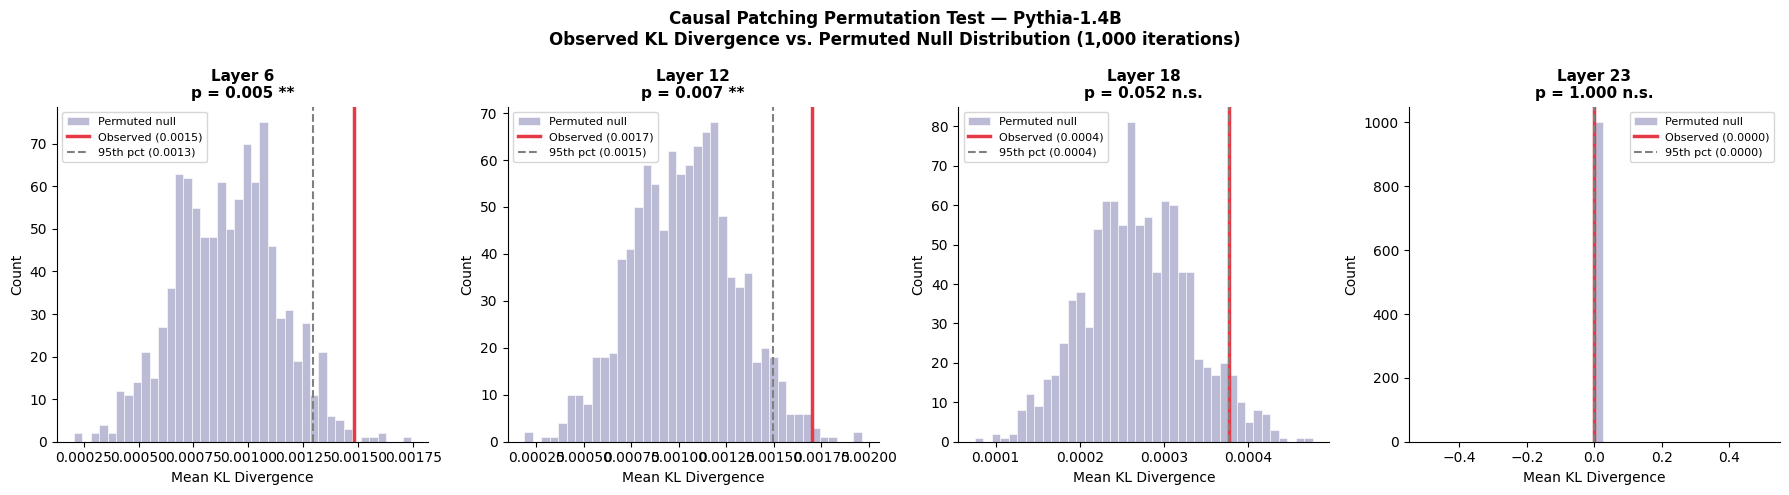


PAPER TEXT:
  Layer 6: observed=0.0015, 95th=0.0013, p=0.0050 **
  Layer 12: observed=0.0017, 95th=0.0015, p=0.0070 **
  Layer 18: observed=0.0004, 95th=0.0004, p=0.0520 n.s.
  Layer 23: observed=0.0000, 95th=0.0000, p=1.0000 n.s.


In [9]:
# Cell 8 — results
print('=' * 65)
print('PERMUTATION TEST RESULTS — Pythia-1.4B')
print('=' * 65)
print()

results_rows = []
for layer in PYTHIA_LAYERS:
    obs   = observed[layer]['mean']
    perms = perm_means[layer]
    pct   = np.percentile(perms, 95)
    p_val = np.mean(np.array(perms) >= obs)
    sig   = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f'Layer {layer}:')
    print(f'  Observed mean KL:    {obs:.4f}')
    print(f'  Permuted 95th pct:   {pct:.4f}')
    print(f'  p-value (one-sided): {p_val:.4f} {sig}')
    results_rows.append({
        'layer': layer, 'observed_kl': round(obs, 4),
        'perm_95th': round(pct, 4),
        'p_value': round(p_val, 4), 'significance': sig
    })
    print()

df = pd.DataFrame(results_rows)
csv_path = f'{OUTPUT_DIR}/patching_permutation_test_pythia14b.csv'
df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

# Figure
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Causal Patching Permutation Test — Pythia-1.4B\n'
             'Observed KL Divergence vs. Permuted Null Distribution (1,000 iterations)',
             fontsize=12, fontweight='bold')

for ax, layer in zip(axes, PYTHIA_LAYERS):
    obs   = observed[layer]['mean']
    perms = perm_means[layer]
    row   = [r for r in results_rows if r['layer'] == layer][0]
    p     = row['p_value']
    sig   = row['significance']

    ax.hist(perms, bins=40, color='#AAAACC', alpha=0.8,
            edgecolor='white', linewidth=0.5, label='Permuted null')
    ax.axvline(obs, color='#E63946', linewidth=2.5,
               label=f'Observed ({obs:.4f})')
    ax.axvline(np.percentile(perms, 95), color='gray',
               linewidth=1.5, linestyle='--',
               label=f'95th pct ({np.percentile(perms,95):.4f})')
    ax.set_title(f'Layer {layer}\np = {p:.3f} {sig}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean KL Divergence', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
fig_path = f'{OUTPUT_DIR}/patching_permutation_test_pythia14b.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'Saved: {fig_path}')
plt.show()

print()
print('PAPER TEXT:')
for row in results_rows:
    print(f'  Layer {row["layer"]}: observed={row["observed_kl"]:.4f}, '
          f'95th={row["perm_95th"]:.4f}, p={row["p_value"]:.4f} {row["significance"]}')